In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_csv('flights_sample_3m.csv')

In [ ]:
df.info() # dataset information

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000000 entries, 0 to 2999999
Data columns (total 32 columns):
 #   Column                   Dtype  
---  ------                   -----  
 0   FL_DATE                  object 
 1   AIRLINE                  object 
 2   AIRLINE_DOT              object 
 3   AIRLINE_CODE             object 
 4   DOT_CODE                 int64  
 5   FL_NUMBER                int64  
 6   ORIGIN                   object 
 7   ORIGIN_CITY              object 
 8   DEST                     object 
 9   DEST_CITY                object 
 10  CRS_DEP_TIME             int64  
 11  DEP_TIME                 float64
 12  DEP_DELAY                float64
 13  TAXI_OUT                 float64
 14  WHEELS_OFF               float64
 15  WHEELS_ON                float64
 16  TAXI_IN                  float64
 17  CRS_ARR_TIME             int64  
 18  ARR_TIME                 float64
 19  ARR_DELAY                float64
 20  CANCELLED                float64
 21  CANCELLA

In [ ]:
df.head() # top 5 rows

,FL_DATE,AIRLINE,AIRLINE_DOT,AIRLINE_CODE,DOT_CODE,FL_NUMBER,ORIGIN,ORIGIN_CITY,DEST,DEST_CITY,...,DIVERTED,CRS_ELAPSED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,DELAY_DUE_CARRIER,DELAY_DUE_WEATHER,DELAY_DUE_NAS,DELAY_DUE_SECURITY,DELAY_DUE_LATE_AIRCRAFT
0,2019-01-09,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,1562,FLL,"Fort Lauderdale, FL",EWR,"Newark, NJ",...,0.0,186.0,176.0,153.0,1065.0,NaN,NaN,NaN,NaN,NaN
1,2022-11-19,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,1149,MSP,"Minneapolis, MN",SEA,"Seattle, WA",...,0.0,235.0,236.0,189.0,1399.0,NaN,NaN,NaN,NaN,NaN
2,2022-07-22,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,459,DEN,"Denver, CO",MSP,"Minneapolis, MN",...,0.0,118.0,112.0,87.0,680.0,NaN,NaN,NaN,NaN,NaN
3,2023-03-06,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,2295,MSP,"Minneapolis, MN",SFO,"San Francisco, CA",...,0.0,260.0,285.0,249.0,1589.0,0.0,0.0,24.0,0.0,0.0
4,2020-02-23,Spirit Air Lines,Spirit Air Lines: NK,NK,20416,407,MCO,"Orlando, FL",DFW,"Dallas/Fort Worth, TX",...,0.0,181.0,182.0,153.0,985.0,NaN,NaN,NaN,NaN,NaN


In [ ]:
df.isnull().sum() # missing values

,0
FL_DATE,0
AIRLINE,0
AIRLINE_DOT,0
AIRLINE_CODE,0
DOT_CODE,0
FL_NUMBER,0
ORIGIN,0
ORIGIN_CITY,0
DEST,0
DEST_CITY,0


In [ ]:

df.duplicated().sum() # duplicate rows

np.int64(0)

In [ ]:
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)


In [ ]:
# Check duplicates
dup_count = df.duplicated().sum()
print("Duplicate rows:", dup_count)

Duplicate rows: 0


In [ ]:
# Quick stats for numeric cols
df.describe(include=[np.number]).T.head(10)


,count,mean,std,min,25%,50%,75%,max
DOT_CODE,3000000.0,19976.294095,377.284619,19393.0,19790.0,19930.0,20368.0,20452.0
FL_NUMBER,3000000.0,2511.535519,1747.258040,1.0,1051.0,2152.0,3797.0,9562.0
CRS_DEP_TIME,3000000.0,1327.061984,485.878854,1.0,915.0,1320.0,1730.0,2359.0
DEP_TIME,2922385.0,1329.775913,499.310052,1.0,916.0,1323.0,1739.0,2400.0
DEP_DELAY,2922356.0,10.123326,49.251835,-90.0,-6.0,-2.0,6.0,2966.0
TAXI_OUT,2921194.0,16.643046,9.192901,1.0,11.0,14.0,19.0,184.0
WHEELS_OFF,2921194.0,1352.360989,500.872687,1.0,931.0,1336.0,1752.0,2400.0
WHEELS_ON,2920056.0,1462.499569,527.236818,1.0,1049.0,1501.0,1908.0,2400.0
TAXI_IN,2920056.0,7.678982,6.269639,1.0,4.0,6.0,9.0,249.0
CRS_ARR_TIME,3000000.0,1490.560665,511.547566,1.0,1107.0,1516.0,1919.0,2400.0


In [ ]:
# convert date columns
df["FL_DATE"] = pd.to_datetime(df["FL_DATE"], errors="coerce")

df["YEAR"] = df["FL_DATE"].dt.year # Extract the year from the 'FL_DATE' and store it in a new 'YEAR' column.

df["MONTH"] = df["FL_DATE"].dt.month # Extract the month from the 'FL_DATE' and store it in a new 'MONTH' column.

df["DAY"] = df["FL_DATE"].dt.day # Extract the day of the month from the 'FL_DATE' and store it in a new 'DAY' column.

df["DAY_OF_WEEK"] = df["FL_DATE"].dt.dayofweek # Extract the day of the week (0=Monday, 6=Sunday) and store it in a new 'DAY_OF_WEEK' column.

df["IS_WEEKEND"] = df["DAY_OF_WEEK"].isin([5, 6]).astype(int) # Create a binary column 'IS_WEEKEND' (1 if it's a Saturday or Sunday, 0 otherwise).


In [ ]:
def hhmm_to_minutes(x):
    """Convert hhmm (e.g., 930 for 9:30 AM) to total minutes from midnight."""
    if pd.isna(x):
        return np.nan
    x = int(x)
    hh = x // 100  # Extract hours
    mm = x % 100   # Extract minutes
    # Validate hour and minute values
    if hh < 0 or hh > 23 or mm < 0 or mm > 59:
        return np.nan
    return hh * 60 + mm # Convert to total minutes from midnight

# Apply the conversion function to scheduled departure time to get minutes from midnight
df["CRS_DEP_MIN"] = df["CRS_DEP_TIME"].apply(hhmm_to_minutes)
# Apply the conversion function to scheduled arrival time to get minutes from midnight
df["CRS_ARR_MIN"] = df["CRS_ARR_TIME"].apply(hhmm_to_minutes)

# Convert minutes from midnight to hours for scheduled departure
df["CRS_DEP_HOUR"] = (df["CRS_DEP_MIN"] // 60).astype("float")
# Convert minutes from midnight to hours for scheduled arrival
df["CRS_ARR_HOUR"] = (df["CRS_ARR_MIN"] // 60).astype("float")

# Display the first few rows of the original CRS_DEP_TIME and the newly created minute and hour columns
df[["CRS_DEP_TIME", "CRS_DEP_MIN", "CRS_DEP_HOUR"]].head()


,CRS_DEP_TIME,CRS_DEP_MIN,CRS_DEP_HOUR
0,1155,715,11.0
1,2120,1280,21.0
2,954,594,9.0
3,1609,969,16.0
4,1840,1120,18.0


In [ ]:
# Keep only non-cancelled flights for delay classification
df = df[df["CANCELLED"] == 0].copy()

# Target: delayed if arrival delay > 15 minutes
df["IS_DELAYED"] = (df["ARR_DELAY"] > 15).astype(int)

df["IS_DELAYED"].value_counts(normalize=True)


,proportion
IS_DELAYED,
0,0.823583
1,0.176417


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

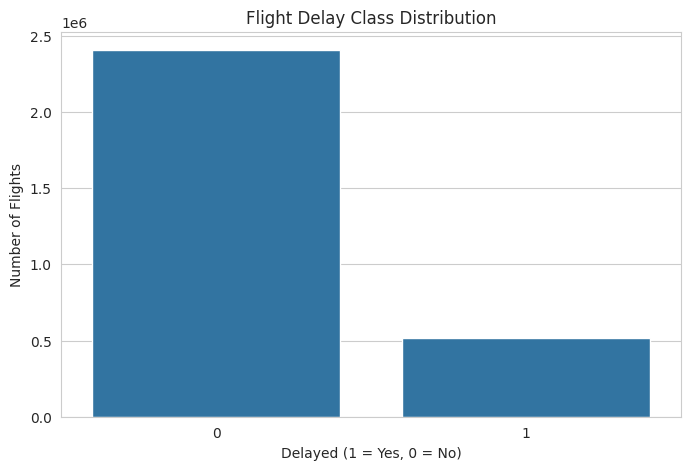

In [ ]:
plt.figure()
sns.countplot(x="IS_DELAYED", data=df)
plt.title("Flight Delay Class Distribution")
plt.xlabel("Delayed (1 = Yes, 0 = No)")
plt.ylabel("Number of Flights")
plt.show()

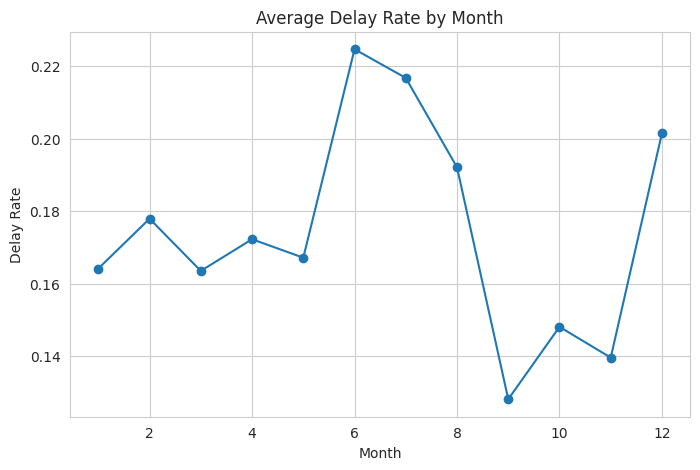

In [ ]:
monthly_delay = df.groupby("MONTH")["IS_DELAYED"].mean()

plt.figure()
monthly_delay.plot(marker="o")
plt.title("Average Delay Rate by Month")
plt.xlabel("Month")
plt.ylabel("Delay Rate")
plt.show()

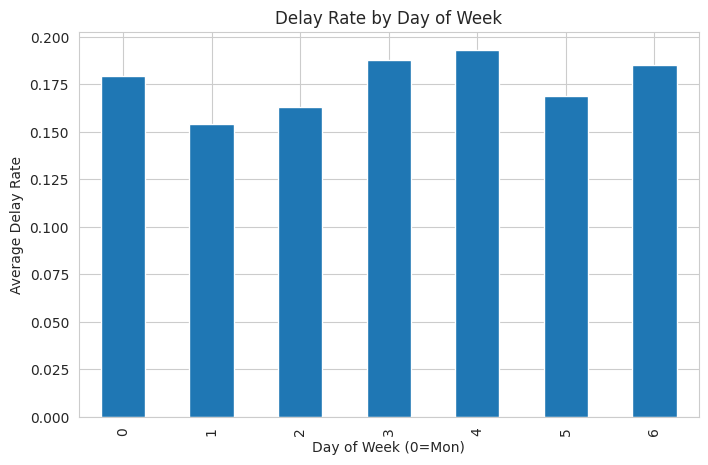

In [ ]:
dow_delay = df.groupby("DAY_OF_WEEK")["IS_DELAYED"].mean()

plt.figure()
dow_delay.plot(kind="bar")
plt.title("Delay Rate by Day of Week")
plt.xlabel("Day of Week (0=Mon)")
plt.ylabel("Average Delay Rate")
plt.show()


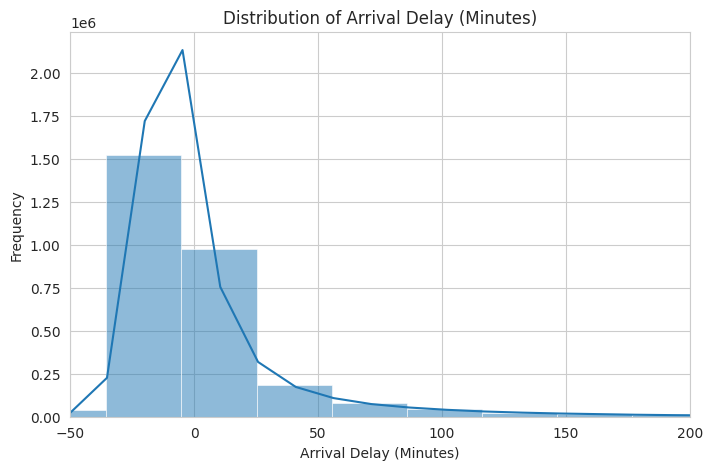

In [ ]:
plt.figure()
sns.histplot(df["ARR_DELAY"], bins=100, kde=True)
plt.xlim(-50, 200)  # focus on realistic range
plt.title("Distribution of Arrival Delay (Minutes)")
plt.xlabel("Arrival Delay (Minutes)")
plt.ylabel("Frequency")
plt.show()


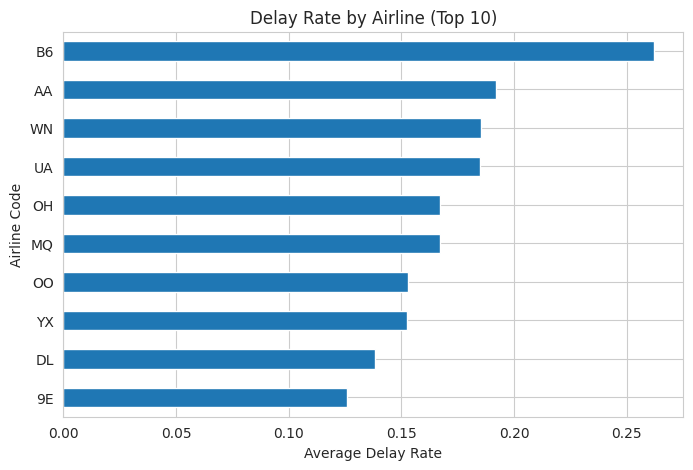

In [ ]:
top_airlines = df["AIRLINE_CODE"].value_counts().nlargest(10).index

airline_delay = (
    df[df["AIRLINE_CODE"].isin(top_airlines)]
    .groupby("AIRLINE_CODE")["IS_DELAYED"]
    .mean()
    .sort_values()
)

plt.figure()
airline_delay.plot(kind="barh")
plt.title("Delay Rate by Airline (Top 10)")
plt.xlabel("Average Delay Rate")
plt.ylabel("Airline Code")
plt.show()


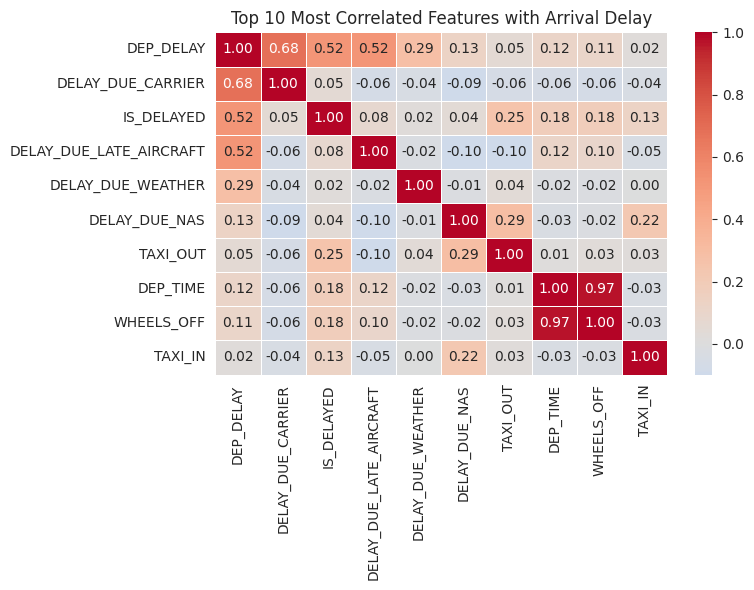

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Select numeric columns only
numeric_df = df.select_dtypes(include=['number'])

# Compute correlation with ARR_DELAY (or IS_DELAYED if using binary target)
arr_delay_corr = numeric_df.corr(numeric_only=True)["ARR_DELAY"].abs().sort_values(ascending=False)

# Select top 10 most correlated features (excluding ARR_DELAY itself)
top_features = arr_delay_corr.index[1:11]

# Create correlation matrix for those features
top_corr_matrix = numeric_df[top_features].corr()

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(
    top_corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Top 10 Most Correlated Features with Arrival Delay")
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import HistGradientBoostingClassifier

In [ ]:
feature_cols = [
    "AIRLINE_CODE",
    "ORIGIN",
    "DEST",
    "CRS_ELAPSED_TIME",
    "DISTANCE",
    "DIVERTED",
    "YEAR",
    "MONTH",
    "DAY",
    "DAY_OF_WEEK",
    "IS_WEEKEND",
    "CRS_DEP_HOUR",
    "CRS_ARR_HOUR"
]

target_col = "IS_DELAYED"

df_model = df[feature_cols + [target_col]].copy()

print("Model dataset shape:", df_model.shape)
df_model.head()

Model dataset shape: (2920860, 14)


,AIRLINE_CODE,ORIGIN,DEST,CRS_ELAPSED_TIME,DISTANCE,DIVERTED,YEAR,MONTH,DAY,DAY_OF_WEEK,IS_WEEKEND,CRS_DEP_HOUR,CRS_ARR_HOUR,IS_DELAYED
0,UA,FLL,EWR,186.0,1065.0,0.0,2019,1,9,2,0,11.0,15.0,0
1,DL,MSP,SEA,235.0,1399.0,0.0,2022,11,19,5,1,21.0,23.0,0
2,UA,DEN,MSP,118.0,680.0,0.0,2022,7,22,4,0,9.0,12.0,0
3,DL,MSP,SFO,260.0,1589.0,0.0,2023,3,6,0,0,16.0,18.0,1
4,NK,MCO,DFW,181.0,985.0,0.0,2020,2,23,6,1,18.0,20.0,0


In [ ]:
sample_size = 120000

if len(df_model) > sample_size:
    df_model = df_model.sample(n=sample_size, random_state=42)

print("Sampled shape:", df_model.shape)
print("\nTarget distribution:")
print(df_model[target_col].value_counts(normalize=True))

Sampled shape: (120000, 14)

Target distribution:
IS_DELAYED
0    0.8234
1    0.1766
Name: proportion, dtype: float64


In [ ]:
cat_cols = ["AIRLINE_CODE", "ORIGIN", "DEST"]

num_cols = [
    "CRS_ELAPSED_TIME",
    "DISTANCE",
    "DIVERTED",
    "YEAR",
    "MONTH",
    "DAY",
    "DAY_OF_WEEK",
    "IS_WEEKEND",
    "CRS_DEP_HOUR",
    "CRS_ARR_HOUR"
]

In [ ]:
tree_preprocess = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median"), num_cols),
        ("cat", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("ordinal", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
        ]), cat_cols)
    ]
)

In [ ]:
log_preprocess = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median"), num_cols),
        ("cat", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), cat_cols)
    ]
)

In [ ]:
X = df_model[feature_cols]
y = df_model[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (96000, 13)
Test shape: (24000, 13)


# Logistic regression

In [ ]:
log_model = Pipeline(steps=[
    ("preprocess", log_preprocess),
    ("model", LogisticRegression(
        max_iter=300,
        solver="saga",
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)
y_prob_log = log_model.predict_proba(X_test)[:, 1]

print("Logistic Regression Results")
print("Accuracy :", round(accuracy_score(y_test, y_pred_log), 4))
print("Precision:", round(precision_score(y_test, y_pred_log), 4))
print("Recall   :", round(recall_score(y_test, y_pred_log), 4))
print("F1 Score :", round(f1_score(y_test, y_pred_log), 4))
print("ROC AUC  :", round(roc_auc_score(y_test, y_prob_log), 4))

Logistic Regression Results
Accuracy : 0.5658
Precision: 0.2275
Recall   : 0.609
F1 Score : 0.3313
ROC AUC  : 0.6032


# Decision Tree Classifier

In [ ]:
X_train_tree = tree_preprocess.fit_transform(X_train)
X_test_tree = tree_preprocess.transform(X_test)
dt_model = DecisionTreeClassifier(
    max_depth=8,
    min_samples_split=100,
    min_samples_leaf=30,
    class_weight="balanced",
    random_state=42
)

dt_model.fit(X_train_tree, y_train)

y_pred_dt = dt_model.predict(X_test_tree)
y_prob_dt = dt_model.predict_proba(X_test_tree)[:, 1]

print("Decision Tree Results")
print("Accuracy :", round(accuracy_score(y_test, y_pred_dt), 4))
print("Precision:", round(precision_score(y_test, y_pred_dt), 4))
print("Recall   :", round(recall_score(y_test, y_pred_dt), 4))
print("F1 Score :", round(f1_score(y_test, y_pred_dt), 4))
print("ROC AUC  :", round(roc_auc_score(y_test, y_prob_dt), 4))

Decision Tree Results
Accuracy : 0.6054
Precision: 0.2494
Recall   : 0.6144
F1 Score : 0.3548
ROC AUC  : 0.6471


# XG Boost Classifier

In [ ]:
from xgboost import XGBClassifier
# Calculate scale_pos_weight for class imbalance

neg_count = y_train.value_counts()[0]
pos_count = y_train.value_counts()[1]

scale_pos_weight_value = neg_count / pos_count

print(f"Scale Pos Weight: {scale_pos_weight_value:.2f}")

Scale Pos Weight: 4.66


In [ ]:
xgb_model = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False,
    n_estimators=200,
    learning_rate=0.08,
    max_depth=6,
    subsample=0.7,
    colsample_bytree=0.7,
    gamma=0.1,
    random_state=42,
    n_jobs=-1,
    scale_pos_weight=scale_pos_weight_value
)
xgb_model.fit(X_train_tree, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.7, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=0.1,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.08, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=-1,
              num_parallel_tree=None, ...)

In [ ]:
y_pred_xgb = xgb_model.predict(X_test_tree)
y_prob_xgb = xgb_model.predict_proba(X_test_tree)[:, 1]
print("\nXGBoost Classifier Results:")

print("Accuracy :", round(accuracy_score(y_test, y_pred_xgb), 4))
print("Precision:", round(precision_score(y_test, y_pred_xgb), 4))
print("Recall   :", round(recall_score(y_test, y_pred_xgb), 4))
print("F1 Score :", round(f1_score(y_test, y_pred_xgb), 4))
print("ROC AUC  :", round(roc_auc_score(y_test, y_prob_xgb), 4))


XGBoost Classifier Results:
Accuracy : 0.6503
Precision: 0.2735
Recall   : 0.5918
F1 Score : 0.3741
ROC AUC  : 0.6794


# Comparison of All Models

In [ ]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "XGBoost (Balanced)"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_xgb)
    ],
    "Precision": [
        precision_score(y_test, y_pred_log),
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_xgb)
    ],
    "Recall": [
        recall_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_xgb)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_xgb)
    ],
    "ROC AUC": [
        roc_auc_score(y_test, y_prob_log),
        roc_auc_score(y_test, y_prob_dt),
        roc_auc_score(y_test, y_prob_xgb)
    ]
})

print("\nModel Comparison:")
print(results.round(4))


Model Comparison:
                 Model  Accuracy  Precision  Recall  F1 Score  ROC AUC
0  Logistic Regression    0.5658     0.2275  0.6090    0.3313   0.6032
1        Decision Tree    0.6054     0.2494  0.6144    0.3548   0.6471
2   XGBoost (Balanced)    0.6503     0.2735  0.5918    0.3741   0.6794


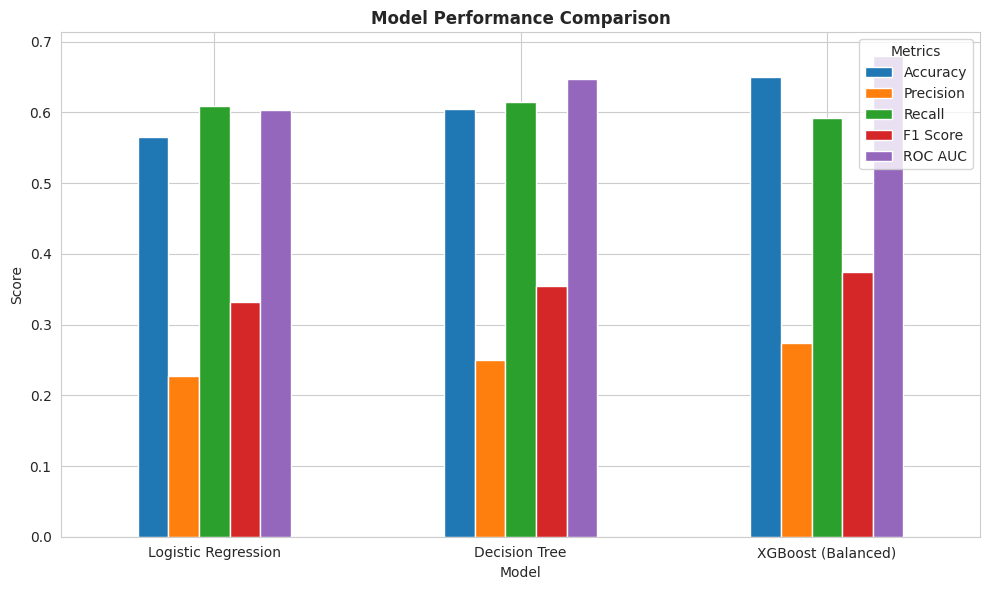

In [ ]:
import matplotlib.pyplot as plt

metrics = ["Accuracy", "Precision", "Recall", "F1 Score", "ROC AUC"]

results_plot = results.set_index("Model")

results_plot[metrics].plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Model Performance Comparison", fontweight="bold")
plt.ylabel("Score")
plt.xlabel("Model")
plt.xticks(rotation=0)

plt.legend(title="Metrics")
plt.tight_layout()

plt.show()

# Best performance model

In [ ]:
best_model_name = results.sort_values("F1 Score", ascending=False).iloc[0]["Model"]
print("Best model based on F1 Score:", best_model_name)

Best model based on F1 Score: XGBoost (Balanced)


# Confusion matrix

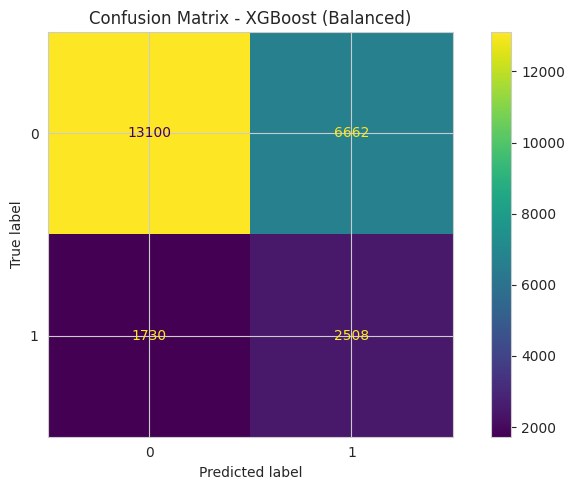

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

if best_model_name == "Logistic Regression":
    best_pred = y_pred_log
elif best_model_name == "Decision Tree":
    best_pred = y_pred_dt
else:
    best_pred = y_pred_xgb

ConfusionMatrixDisplay.from_predictions(y_test, best_pred)
plt.title(f"Confusion Matrix - {best_model_name}")
plt.tight_layout()
plt.show()

# feature Importance

In [ ]:
tree_feature_names = num_cols + cat_cols

feature_importance = pd.DataFrame({
    "Feature": tree_feature_names,
    "Importance": dt_model.feature_importances_
}).sort_values("Importance", ascending=False)

print(feature_importance.head(10))

             Feature  Importance
8       CRS_DEP_HOUR    0.315238
3               YEAR    0.209507
4              MONTH    0.138579
10      AIRLINE_CODE    0.077948
9       CRS_ARR_HOUR    0.067789
1           DISTANCE    0.052112
5                DAY    0.051541
0   CRS_ELAPSED_TIME    0.041240
12              DEST    0.018906
11            ORIGIN    0.016550


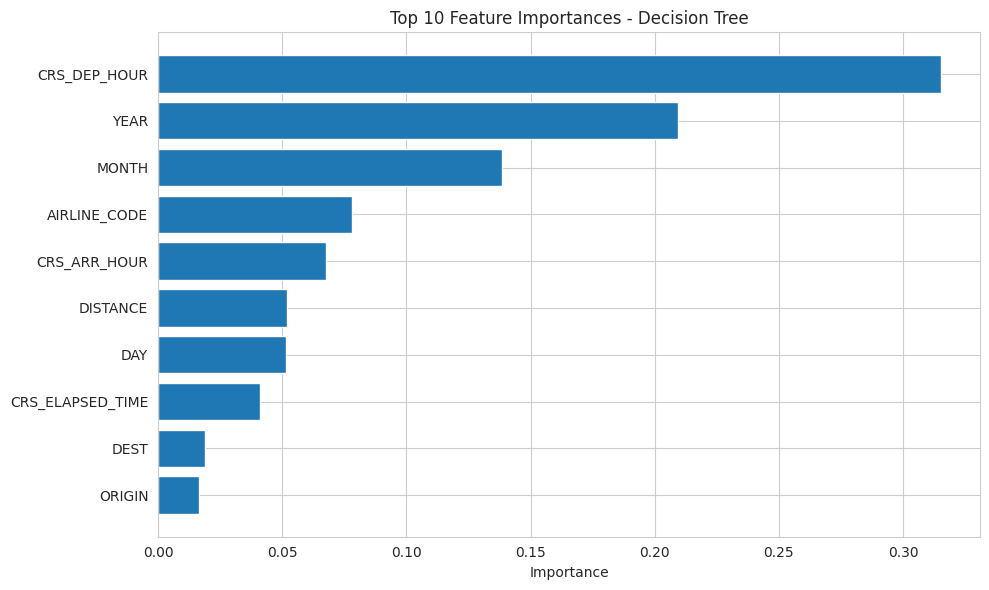

In [ ]:
top_features = feature_importance.head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.gca().invert_yaxis()
plt.title("Top 10 Feature Importances - Decision Tree")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

Actual vs Predicted Values

In [ ]:
# Create Actual vs Predicted dataframe

actual_vs_pred = pd.DataFrame({
    "Actual": y_test,
    "Predicted": best_pred
})

print(actual_vs_pred.tail(20))

         Actual  Predicted
1848870       1          0
2421684       1          1
127515        1          0
2653308       0          0
229024        0          1
726101        1          0
2960283       0          0
1998593       0          0
1126767       0          0
64587         0          0
2086932       0          0
2086128       0          0
2890501       1          1
919282        0          1
2396563       0          1
1273694       0          1
233740        0          0
534275        0          1
544897        0          1
2147316       0          0
